# Day 9: Bayesian Optimization And Safe BO

Compare adaptive optimization against space-filling search. This day focuses on sample efficiency, safety constraints, and why BO is a natural baseline for recipe-space experimentation.

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(9)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)


project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day09


In [2]:
tu.display_learning_goal(
    9,
    "Bayesian optimization baselines",
    [
        "Run LHS, GP-BO, and Safe GP-BO under a shared budget.",
        "Plot best-score curves from trajectory JSONL.",
        "Inspect risk behavior under safety-aware optimization.",
        "Explain why BO is preferred over RL for this recipe-space task.",
    ],
)

In [3]:
tu.display_api_card()

In [4]:
tu.display_student_checkpoint(
    9,
    [
        "one convergence plot",
        "one safety comparison table",
        "one explanation of exploitation vs exploration",
    ],
)

In [5]:
from chemworld.data.logging import load_jsonl
from chemworld.eval.metrics import evaluate_records
from chemworld.eval.runner import make_agent, run_agent

agents = ["lhs", "gp_bo", "safe_gp_bo"]
run_rows = []
curves = []
for agent_name in agents:
    path = OUTPUT_DIR / f"{agent_name}_seed0.jsonl"
    run_agent(
        env_id="ChemWorld",
        agent=make_agent(agent_name),
        world_split="public-test",
        budget=66,
        objective="balanced",
        seed=0,
        output_path=path,
    )
    records = load_jsonl(path)
    result = evaluate_records(records).to_dict()
    result["agent"] = agent_name
    run_rows.append(result)
    best = 0.0
    for record in records:
        score = record["leaderboard_score"] or 0.0
        best = max(best, score)
        curves.append(
            {
                "agent": agent_name,
                "step": record["step"],
                "best_score": best,
                "risk": record["observation"]["safety_risk"],
            }
        )
summary_df = pd.DataFrame(run_rows)
curve_df = pd.DataFrame(curves)
display(
    summary_df[
        [
            "agent",
            "steps",
            "final_best_score",
            "safety_violations",
            "mean_safety_risk",
            "total_score",
        ]
    ]
)

,agent,steps,final_best_score,safety_violations,mean_safety_risk,total_score
0,lhs,6,0.0010,0,0.2373,0.0006
1,gp_bo,6,0.0143,0,0.1287,0.0085
2,safe_gp_bo,6,0.0143,0,0.1287,0.0085


C:\Users\Admin\AppData\Local\Temp\ipykernel_26344\4098194401.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")


agent,step,gp_bo,lhs,safe_gp_bo
1,2,0.0000,0.000,0.0000
2,3,0.0000,0.000,0.0000
3,4,0.0000,0.000,0.0000
4,5,0.0000,0.000,0.0000
5,6,0.0143,0.001,0.0143


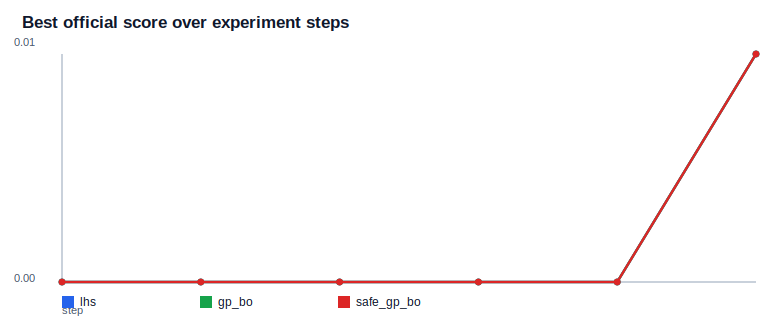

In [6]:
plot_df = (
    curve_df.pivot_table(index="step", columns="agent", values="best_score", aggfunc="max")
    .reset_index()
    .fillna(method="ffill")
    .fillna(0.0)
)
display(plot_df.tail())
display(
    tu.line_svg(plot_df, x="step", ys=agents, title="Best official score over experiment steps")
)

,agent,mean_step_risk,total_score,safety_violations
0,gp_bo,0.1287,0.0085,0
1,lhs,0.2373,0.0006,0
2,safe_gp_bo,0.1287,0.0085,0


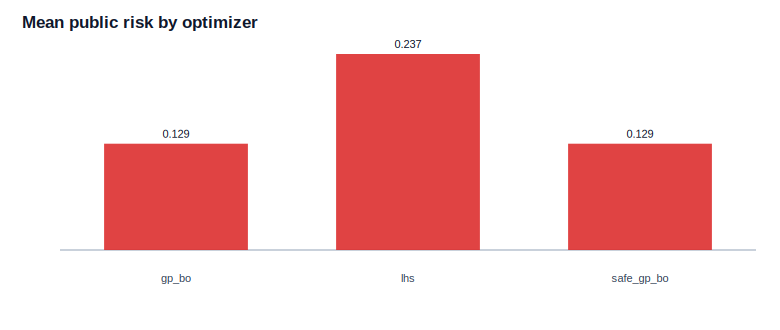

In [7]:
risk_df = (
    curve_df.groupby("agent", as_index=False)["risk"]
    .mean()
    .rename(columns={"risk": "mean_step_risk"})
)
risk_df = risk_df.merge(summary_df[["agent", "total_score", "safety_violations"]], on="agent")
display(risk_df)
display(
    tu.bar_svg(
        risk_df["agent"].tolist(),
        risk_df["mean_step_risk"].astype(float).tolist(),
        title="Mean public risk by optimizer",
        color="#dc2626",
    )
)

In [8]:
interpretation = {
    "bo_role": (
        "BO builds a local surrogate from finished recipes and uses uncertainty "
        "to choose the next recipe."
    ),
    "safe_bo_role": "Safe BO penalizes candidates whose predicted risk is too high.",
    "why_not_rl_yet": (
        "The current task is low-dimensional recipe optimization. RL becomes more useful "
        "for longer multi-step control tasks such as heating profiles or feed policies."
    ),
}
tu.show_json_panel("Optimizer interpretation", interpretation)
